# Лабораторная работа № 2 — Линейная и логистическая регрессия

**Сквозной кейс:** прогнозировать `PageValues` (регрессия) и вероятность `Revenue=True` (классификация), исследовать порог, градиентный спуск и регуляризацию.

Работа организована по методическим указаниям и использует разбиение **train/validation/test = 60%/20%/20%**, `random_state=42`, preprocessing внутри `Pipeline` и выбор гиперпараметров/порогов только на validation.

> Перед запуском положить рядом с notebook файл `online_shoppers_intention.csv`. При его отсутствии код попробует скачать официальный CSV UCI по URL из задания.

## 0. Импорт библиотек и воспроизводимость

In [9]:
import sys
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import (
    LinearRegression, Ridge, HuberRegressor,
    LogisticRegression, SGDClassifier
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, roc_curve, precision_recall_curve,
    brier_score_loss, root_mean_squared_error
)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Python:', sys.version)
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn_version)

Python: 3.11.0 (v3.11.0:deaf509e8f, Oct 24 2022, 14:43:23) [Clang 13.0.0 (clang-1300.0.29.30)]
pandas: 3.0.6
scikit-learn: 1.9.1


## 1. Загрузка данных

In [10]:
DATA_LOCAL = Path('online_shoppers_intention.csv')
DATA_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv'

if DATA_LOCAL.exists():
    df = pd.read_csv(DATA_LOCAL)
    data_source = str(DATA_LOCAL)
else:
    # fallback: официальный URL из методички
    df = pd.read_csv(DATA_URL)
    data_source = DATA_URL

print('Источник:', data_source)
print('Shape:', df.shape)
display(df.head())

Источник: online_shoppers_intention.csv
Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### 1.1. Аудит структуры, пропусков, дубликатов и баланса цели

In [11]:
audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'n_unique': df.nunique(dropna=False)
})
print('Дубликатов:', int(df.duplicated().sum()))
print('Пропусков всего:', int(df.isna().sum().sum()))
display(audit)

revenue_counts = df['Revenue'].value_counts(dropna=False).rename('count')
revenue_share = df['Revenue'].mean()
print('Revenue=True:', int(revenue_counts.get(True, 0)))
print('Revenue=False:', int(revenue_counts.get(False, 0)))
print('Доля positive:', revenue_share)

# Тривиальный классификатор всегда False
majority_accuracy = (df['Revenue'] == False).mean()
print('Accuracy классификатора «всегда False»:', majority_accuracy)
print('Recall положительного класса:', 0.0)

Дубликатов: 125
Пропусков всего: 0


,dtype,missing,n_unique
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


Revenue=True: 1908
Revenue=False: 10422
Доля positive: 0.15474452554744525
Accuracy классификатора «всегда False»: 0.8452554744525548
Recall положительного класса: 0.0


### 1.2. Группы признаков и распределения

In [12]:
num_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]
cat_cols = [
    'Month', 'OperatingSystems', 'Browser', 'Region',
    'TrafficType', 'VisitorType', 'Weekend'
]
binary_cols = ['Weekend', 'Revenue']

print('Числовые признаки:', num_cols)
print('Категориальные признаки:', cat_cols)
print('Бинарные признаки:', binary_cols)

display(df[num_cols].describe().T)

Числовые признаки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Категориальные признаки: ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
Бинарные признаки: ['Weekend', 'Revenue']


,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


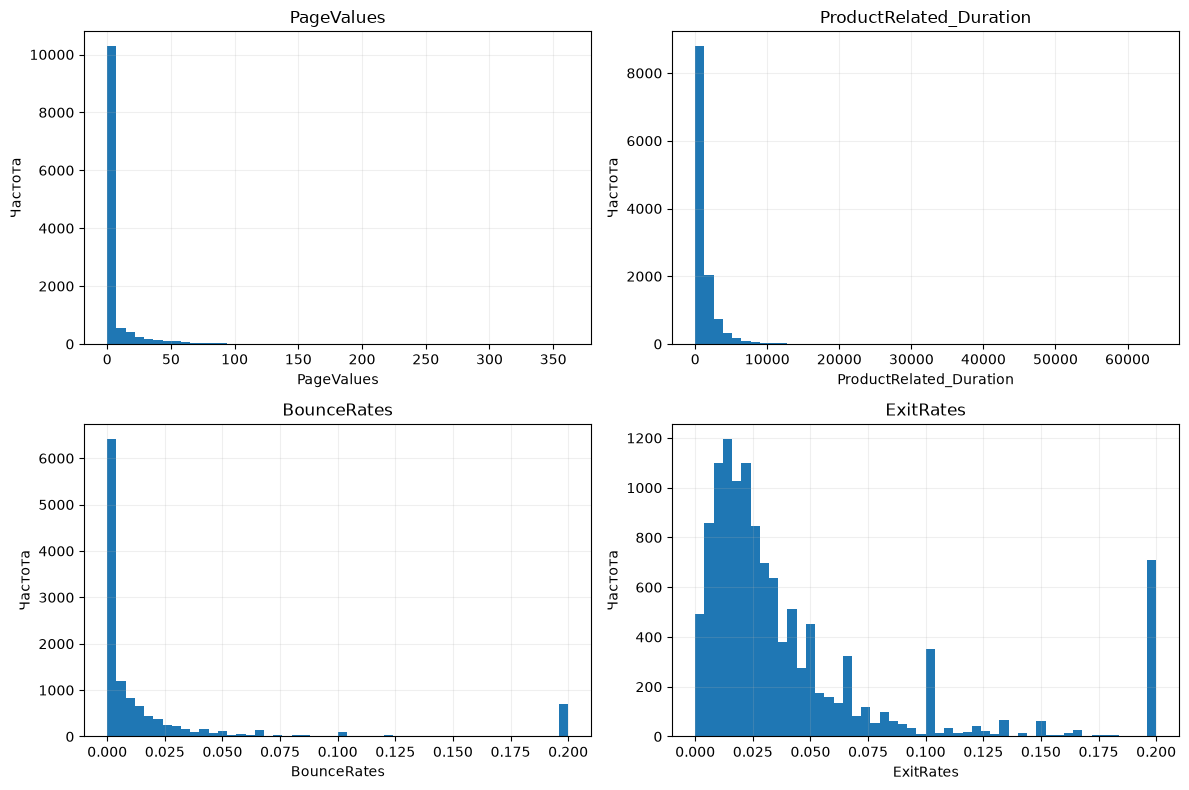

In [13]:
plot_cols = ['PageValues', 'ProductRelated_Duration', 'BounceRates', 'ExitRates']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), plot_cols):
    ax.hist(df[col].astype(float), bins=50)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Частота')
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 1.3. Leakage / temporal mismatch — минимум два риска

1. **`PageValues` как потенциально постфактум-признак.** В методичке он исключён из раннего purchase-intent baseline, потому что этот показатель связан с ценностью страниц перед транзакцией и может быть недоступен в момент раннего решения.
2. **`Revenue` — прямой исход события.** Использование `Revenue` среди признаков для любого прогноза привело бы к target leakage.
3. **Временной mismatch.** В наборе есть `Month`, но нет года и точной временной метки; поэтому holdout по месяцам не даёт полноценной хронологической проверки на будущий период.

## 2. Общие функции preprocessing и split

In [14]:
# Для всех обязательных экспериментов — 60/20/20.
# В regression split используется без stratify, в classification — с stratify.

def make_preprocessor(num_features, cat_features, dense=False):
    ohe_kwargs = {'handle_unknown': 'ignore'}
    if dense:
        ohe_kwargs['sparse_output'] = False
    return ColumnTransformer([
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_features),
        ('cat', OneHotEncoder(**ohe_kwargs), cat_features)
    ])


def regression_split(X, y):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.4, random_state=RANDOM_STATE
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
    )
    return X_tr, X_val, X_te, y_tr, y_val, y_te


def classification_split(X, y):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=RANDOM_STATE
    )
    return X_tr, X_val, X_te, y_tr, y_val, y_te

## 3. Задание 2 — Линейная регрессия для `PageValues`

Цель: прогнозировать `PageValues`, не используя `Revenue`. Сравниваются `DummyRegressor`, `LinearRegression`, `Ridge` и устойчивый `HuberRegressor`. Дополнительно проверяется `log1p`-преобразование target.

In [15]:
reg_features = num_cols.copy()
reg_features.remove('PageValues')
Xr = df[reg_features + cat_cols]
yr = df['PageValues'].astype(float)

Xr_tr, Xr_val, Xr_te, yr_tr, yr_val, yr_te = regression_split(Xr, yr)
print('Размеры regression split:', len(Xr_tr), len(Xr_val), len(Xr_te))

reg_prep = make_preprocessor(reg_features, cat_cols, dense=True)

reg_models = {
    'DummyRegressor': Pipeline([('prep', reg_prep), ('model', DummyRegressor(strategy='mean'))]),
    'LinearRegression': Pipeline([('prep', reg_prep), ('model', LinearRegression())]),
    'Ridge(alpha=10)': Pipeline([('prep', reg_prep), ('model', Ridge(alpha=10.0))]),
    'HuberRegressor': Pipeline([('prep', reg_prep), ('model', HuberRegressor(max_iter=2000, epsilon=1.35))]),
}

reg_rows = []
reg_preds = {}
for name, model in reg_models.items():
    model.fit(Xr_tr, yr_tr)
    pv = model.predict(Xr_val)
    pt = model.predict(Xr_te)
    reg_preds[name] = (pv, pt)
    for split_name, y_true, pred in [('validation', yr_val, pv), ('test', yr_te, pt)]:
        reg_rows.append({
            'model': name,
            'split': split_name,
            'MAE': mean_absolute_error(y_true, pred),
            'RMSE': root_mean_squared_error(y_true, pred),
            'R2': r2_score(y_true, pred)
        })

reg_results = pd.DataFrame(reg_rows)
display(reg_results.round(4))

Размеры regression split: 7398 2466 2466


,model,split,MAE,RMSE,R2
0,DummyRegressor,validation,9.4825,18.9190,-0.0000
1,DummyRegressor,test,9.2169,17.7680,-0.0004
2,LinearRegression,validation,9.1882,18.3557,0.0587
3,LinearRegression,test,9.1219,17.4480,0.0353
4,Ridge(alpha=10),validation,9.1385,18.3145,0.0629
5,Ridge(alpha=10),test,9.0979,17.4219,0.0382
6,HuberRegressor,validation,5.9486,19.8240,-0.0980
7,HuberRegressor,test,5.6180,18.6241,-0.0991


### 3.1. `log1p(PageValues)`

Используем `TransformedTargetRegressor`: модель обучается на `log1p(y)`, а прогноз автоматически возвращается через обратное преобразование `expm1`. Интерпретация: если модель предсказывает `z` в лог-шкале, исходная шкала — `expm1(z) = exp(z)-1`. Преобразование снижает влияние длинного правого хвоста, но не делает ошибки в исходной шкале симметричными.

In [18]:
base_linear = Pipeline([('prep', reg_prep), ('model', Ridge(alpha=10.0))])
log_ridge = TransformedTargetRegressor(
    regressor=base_linear,
    func=np.log1p,
    inverse_func=np.expm1
)
log_ridge.fit(Xr_tr, yr_tr)
pv_log = log_ridge.predict(Xr_val)
pt_log = log_ridge.predict(Xr_te)

log1p_rows = pd.DataFrame([
    {'model': 'Ridge + log1p target', 'split': 'validation',
     'MAE': mean_absolute_error(yr_val, pv_log),
     'RMSE': root_mean_squared_error(yr_val, pv_log),
     'R2': r2_score(yr_val, pv_log)},
    {'model': 'Ridge + log1p target', 'split': 'test',
     'MAE': mean_absolute_error(yr_te, pt_log),
     'RMSE': root_mean_squared_error(yr_te, pt_log),
     'R2': r2_score(yr_te, pt_log)},
])
display(log1p_rows.round(4))

,model,split,MAE,RMSE,R2
0,Ridge + log1p target,validation,6.3323,19.6120,-0.0746
1,Ridge + log1p target,test,5.9984,18.2024,-0.0499


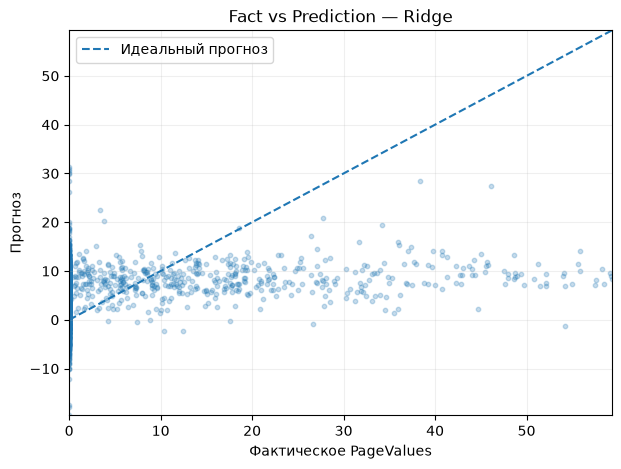

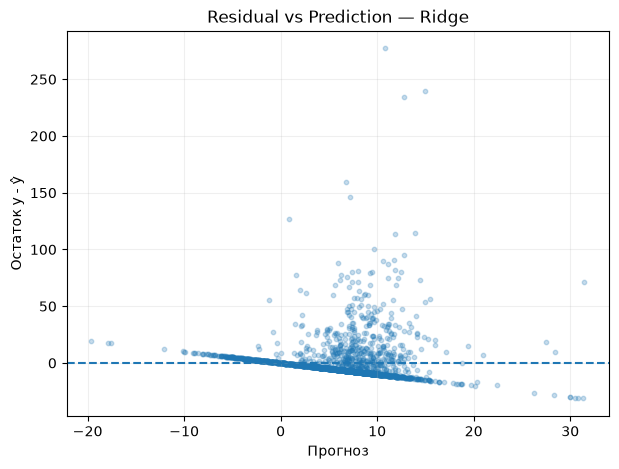

In [19]:
# Fact-vs-prediction
pred_main = reg_preds['Ridge(alpha=10)'][1]
lim = np.percentile(np.r_[yr_te.values, pred_main], 99)
plt.figure(figsize=(7, 5))
plt.scatter(yr_te, pred_main, s=10, alpha=0.25)
plt.plot([0, lim], [0, lim], '--', label='Идеальный прогноз')
plt.xlim(0, lim)
plt.ylim(min(-2, float(np.nanmin(pred_main))), lim)
plt.xlabel('Фактическое PageValues')
plt.ylabel('Прогноз')
plt.title('Fact vs Prediction — Ridge')
plt.legend(); plt.grid(alpha=0.2); plt.show()

# Residual-vs-prediction
resid = yr_te.values - pred_main
plt.figure(figsize=(7, 5))
plt.scatter(pred_main, resid, s=10, alpha=0.25)
plt.axhline(0, linestyle='--')
plt.xlabel('Прогноз')
plt.ylabel('Остаток y - ŷ')
plt.title('Residual vs Prediction — Ridge')
plt.grid(alpha=0.2); plt.show()

**Интерпретация:** небольшой `R²` не делает модель автоматически бесполезной. Важно сравнивать её с Dummy baseline, смотреть на MAE/RMSE и учитывать форму target. Для `PageValues` ожидаемы нули и длинный хвост, поэтому линейная модель может давать скромный `R²`, оставаясь полезной как baseline и ориентир для следующих моделей.

## 4. Задание 3 — Логистическая регрессия для `Revenue`

Основной ранний baseline **не использует `PageValues`**. Сравниваются `DummyClassifier`, обычная `LogisticRegression`, `class_weight='balanced'` и `SGDClassifier(loss='log_loss')`.

In [20]:
clf_features = [c for c in num_cols if c != 'PageValues'] + cat_cols
Xc = df[clf_features]
yc = df['Revenue'].astype(int)

Xc_tr, Xc_val, Xc_te, yc_tr, yc_val, yc_te = classification_split(Xc, yc)
print('Размеры classification split:', len(Xc_tr), len(Xc_val), len(Xc_te))
print('Positive rate train/val/test:', yc_tr.mean(), yc_val.mean(), yc_te.mean())

clf_prep = make_preprocessor([c for c in num_cols if c != 'PageValues'], cat_cols, dense=True)

clf_models = {
    'DummyClassifier': Pipeline([
        ('prep', clf_prep),
        ('model', DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE))
    ]),
    'LogisticRegression': Pipeline([
        ('prep', clf_prep),
        ('model', LogisticRegression(max_iter=3000, C=1.0, solver='lbfgs'))
    ]),
    'LogisticRegression balanced': Pipeline([
        ('prep', clf_prep),
        ('model', LogisticRegression(max_iter=3000, C=1.0, class_weight='balanced', solver='lbfgs'))
    ]),
    'SGDClassifier log_loss': Pipeline([
        ('prep', clf_prep),
        ('model', SGDClassifier(loss='log_loss', alpha=0.0001, max_iter=3000,
                                tol=1e-4, random_state=RANDOM_STATE))
    ]),
}

clf_rows = []
probs_val = {}
probs_test = {}
for name, model in clf_models.items():
    model.fit(Xc_tr, yc_tr)
    pv = model.predict_proba(Xc_val)[:, 1]
    pt = model.predict_proba(Xc_te)[:, 1]
    probs_val[name] = pv
    probs_test[name] = pt
    pred_v = (pv >= 0.5).astype(int)
    pred_t = (pt >= 0.5).astype(int)
    for split_name, y_true, prob, pred in [
        ('validation', yc_val, pv, pred_v),
        ('test', yc_te, pt, pred_t)
    ]:
        clf_rows.append({
            'model': name,
            'split': split_name,
            'accuracy@0.5': accuracy_score(y_true, pred),
            'precision@0.5': precision_score(y_true, pred, zero_division=0),
            'recall@0.5': recall_score(y_true, pred, zero_division=0),
            'F1@0.5': f1_score(y_true, pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_true, prob),
            'AP': average_precision_score(y_true, prob),
            'log-loss': log_loss(y_true, prob),
        })

clf_results = pd.DataFrame(clf_rows)
display(clf_results.round(4))

Размеры classification split: 7398 2466 2466
Positive rate train/val/test: 0.15477155988104893 0.15450121654501217 0.1549067315490673


,model,split,accuracy@0.5,precision@0.5,recall@0.5,F1@0.5,ROC-AUC,AP,log-loss
0,DummyClassifier,validation,0.8455,0.0000,0.0000,0.0000,0.5000,0.1545,5.5688
1,DummyClassifier,test,0.8451,0.0000,0.0000,0.0000,0.5000,0.1549,5.5834
2,LogisticRegression,validation,0.8423,0.3571,0.0262,0.0489,0.7384,0.3108,0.3809
3,LogisticRegression,test,0.8471,0.5806,0.0471,0.0872,0.7601,0.3695,0.3696
4,LogisticRegression balanced,validation,0.6399,0.2606,0.7244,0.3833,0.7412,0.3135,0.5960
5,LogisticRegression balanced,test,0.6431,0.2720,0.7775,0.4030,0.7598,0.3539,0.5850
6,SGDClassifier log_loss,validation,0.8402,0.3617,0.0446,0.0794,0.7273,0.2934,0.3928
7,SGDClassifier log_loss,test,0.8435,0.4630,0.0654,0.1147,0.7463,0.3214,0.3809


In [21]:
# Confusion matrix для основного LogisticRegression при пороге 0.5 на test
p_test_lr = probs_test['LogisticRegression']
y_hat_lr_05 = (p_test_lr >= 0.5).astype(int)
cm = confusion_matrix(yc_te, y_hat_lr_05)
print('Confusion matrix @0.5:\n', cm)
print('TN, FP, FN, TP =', cm.ravel())

Confusion matrix @0.5:
 [[2071   13]
 [ 364   18]]
TN, FP, FN, TP = [2071   13  364   18]


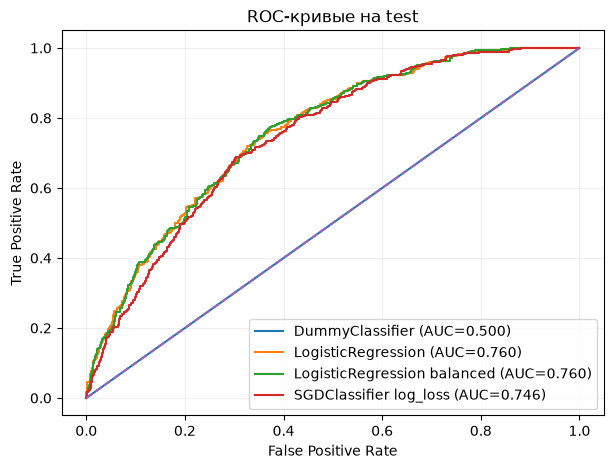

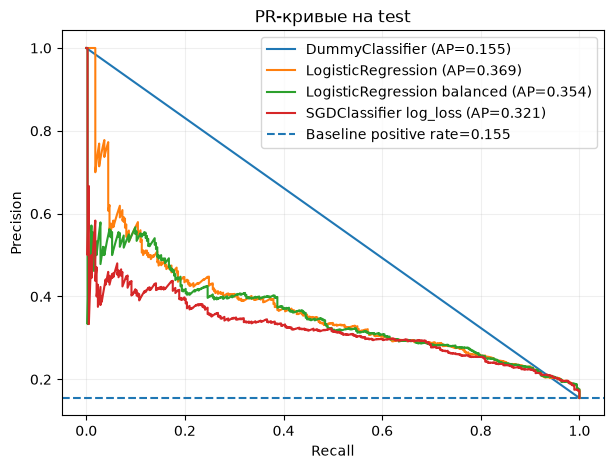

In [22]:
# ROC- и PR-кривые на test
plt.figure(figsize=(7, 5))
for name, p in probs_test.items():
    fpr, tpr, _ = roc_curve(yc_te, p)
    auc = roc_auc_score(yc_te, p)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на test')
plt.legend(); plt.grid(alpha=0.2); plt.show()

plt.figure(figsize=(7, 5))
for name, p in probs_test.items():
    precision, recall, _ = precision_recall_curve(yc_te, p)
    ap = average_precision_score(yc_te, p)
    plt.plot(recall, precision, label=f'{name} (AP={ap:.3f})')
plt.axhline(yc_te.mean(), linestyle='--', label=f'Baseline positive rate={yc_te.mean():.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR-кривые на test')
plt.legend(); plt.grid(alpha=0.2); plt.show()

**Почему AP полезна при дисбалансе?** При положительном классе около 15.5% обычная accuracy может быть высокой даже у модели, которая не находит ни одной покупки. Average Precision концентрируется на качестве ранжирования положительного класса и поэтому лучше отражает задачу поиска относительно редких positive-сессий.

### 4.1. Калибровка вероятностей

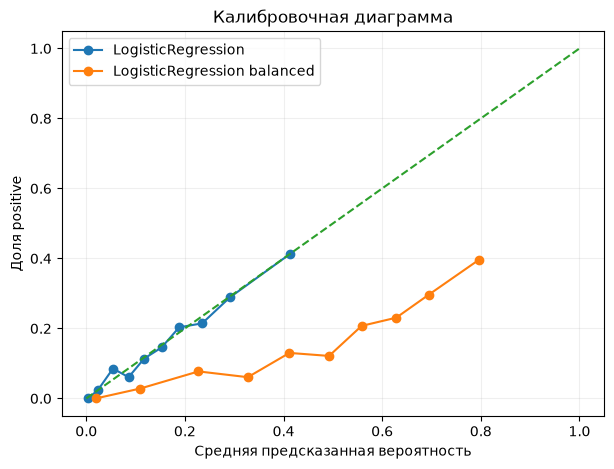

,model,Brier,log-loss
0,LogisticRegression,0.1153,0.3696
1,LogisticRegression balanced,0.2073,0.5850


In [23]:
cal_rows = []
plt.figure(figsize=(7, 5))
for name in ['LogisticRegression', 'LogisticRegression balanced']:
    p = probs_test[name]
    frac_pos, mean_pred = calibration_curve(yc_te, p, n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', label=name)
    cal_rows.append({
        'model': name,
        'Brier': brier_score_loss(yc_te, p),
        'log-loss': log_loss(yc_te, p)
    })
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля positive')
plt.title('Калибровочная диаграмма')
plt.legend(); plt.grid(alpha=0.2); plt.show()

display(pd.DataFrame(cal_rows).round(4))

`class_weight='balanced'` меняет относительные штрафы классов и тем самым сдвигает границу решения. Поэтому его выходные вероятности нельзя автоматически считать откалиброванными для исходной доли positive; калибровочную диаграмму нужно проверять отдельно.

## 5. Задание 4 — порог и utility

Задана функция полезности: **TP=+8, FP=-1, FN=-3, TN=0**. Порог перебирается на validation от 0.01 до 0.99. Дополнительно считается max-F1 threshold. После выбора пороги применяются к test без перенастройки.

In [24]:
def utility(y_true, pred, tp=8, fp=-1, fn=-3, tn=0):
    tn_n, fp_n, fn_n, tp_n = confusion_matrix(y_true, pred).ravel()
    return tp*tp_n + fp*fp_n + fn*fn_n + tn*tn_n

def find_max_utility_threshold(y_true, prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    vals = [utility(y_true, (prob >= t).astype(int)) for t in grid]
    i = int(np.argmax(vals))
    return float(grid[i]), float(vals[i]), np.asarray(vals)

def find_max_f1_threshold(y_true, prob):
    precision, recall, thresholds = precision_recall_curve(y_true, prob)
    f1 = 2*precision*recall / (precision+recall+1e-15)
    i = int(np.argmax(f1[:-1]))
    return float(thresholds[i]), float(f1[i]), precision, recall, thresholds, f1

p_val_lr = probs_val['LogisticRegression']
t_utility, u_val, utility_grid = find_max_utility_threshold(yc_val, p_val_lr)
t_f1, f1_val, precision_v, recall_v, pr_thresholds, f1_curve = find_max_f1_threshold(yc_val, p_val_lr)

thresholds_to_compare = {
    '0.5': 0.5,
    'max-F1(validation)': t_f1,
    'max-utility(validation)': t_utility,
}

threshold_rows = []
for name, t in thresholds_to_compare.items():
    pred_val = (p_val_lr >= t).astype(int)
    pred_test = (p_test_lr >= t).astype(int)
    threshold_rows.append({
        'threshold_name': name,
        'threshold': t,
        'validation_utility': utility(yc_val, pred_val),
        'test_utility': utility(yc_te, pred_test),
        'test_precision': precision_score(yc_te, pred_test, zero_division=0),
        'test_recall': recall_score(yc_te, pred_test, zero_division=0),
        'test_F1': f1_score(yc_te, pred_test, zero_division=0),
        'test_accuracy': accuracy_score(yc_te, pred_test),
    })
threshold_results = pd.DataFrame(threshold_rows)
print(f'max-F1 threshold = {t_f1:.6f}, validation F1 = {f1_val:.6f}')
print(f'max-utility threshold = {t_utility:.6f}, validation utility = {u_val:.0f}')
display(threshold_results.round(4))

max-F1 threshold = 0.214244, validation F1 = 0.395108
max-utility threshold = 0.070000, validation utility = 1414


,threshold_name,threshold,validation_utility,test_utility,test_precision,test_recall,test_F1,test_accuracy
0,0.5,0.5000,-1051,-961,0.5806,0.0471,0.0872,0.8471
1,max-F1(validation),0.2142,695,779,0.3077,0.5759,0.4011,0.7336
2,max-utility(validation),0.0700,1414,1388,0.2057,0.9293,0.3368,0.4331


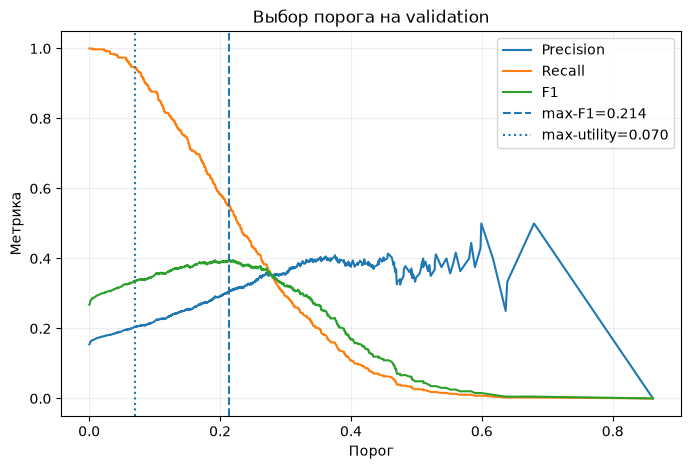

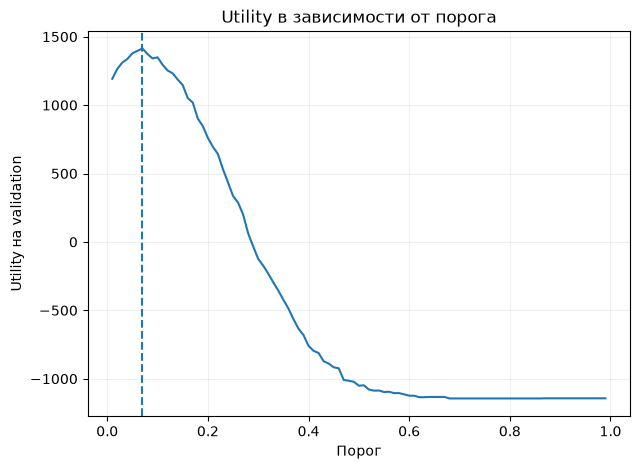

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(pr_thresholds, precision_v[:-1], label='Precision')
plt.plot(pr_thresholds, recall_v[:-1], label='Recall')
plt.plot(pr_thresholds, f1_curve[:-1], label='F1')
plt.axvline(t_f1, linestyle='--', label=f'max-F1={t_f1:.3f}')
plt.axvline(t_utility, linestyle=':', label=f'max-utility={t_utility:.3f}')
plt.xlabel('Порог')
plt.ylabel('Метрика')
plt.title('Выбор порога на validation')
plt.legend(); plt.grid(alpha=0.2); plt.show()

plt.figure(figsize=(7, 5))
grid = np.linspace(0.01, 0.99, 99)
plt.plot(grid, utility_grid)
plt.axvline(t_utility, linestyle='--')
plt.xlabel('Порог')
plt.ylabel('Utility на validation')
plt.title('Utility в зависимости от порога')
plt.grid(alpha=0.2); plt.show()

Порог 0.5 является лишь техническим соглашением, а не обязательным правилом. В этой лабораторной окончательная бизнес-настройка порога определяется заданной функцией utility и выполняется только на validation.

## 6. Задание 5 — градиентный спуск с нуля

Реализуются stable sigmoid, log-loss, аналитический градиент, finite-difference gradient check, batch GD для `η ∈ {0.001, 0.01, 0.1, 1.0}`, mini-batch размеры `1, 32, 256, n` и momentum `β=0.9`.

Для reproducibility используем небольшую согласованную числовую подвыборку признаков и стандартизацию **только по train**.

In [27]:
gd_features = [
    'Administrative_Duration', 'ProductRelated',
    'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay'
]

Xg = df[gd_features].astype(float).to_numpy()
yg = yc.to_numpy().astype(float)

# First split: train (60%) vs temp (40%)
Xg_tr, Xg_tmp, yg_tr, yg_tmp = train_test_split(
    Xg, yg, test_size=0.4, stratify=yg, random_state=RANDOM_STATE
)

# Second split: val (20%) vs test (20%)
Xg_val, Xg_te, yg_val, yg_te = train_test_split(
    Xg_tmp, yg_tmp, test_size=0.5, stratify=yg_tmp, random_state=RANDOM_STATE
)

# Standardize using train statistics only
mu = Xg_tr.mean(axis=0)
sd = Xg_tr.std(axis=0)
sd[sd == 0] = 1.0
Xg_tr_s  = (Xg_tr  - mu) / sd
Xg_val_s = (Xg_val - mu) / sd
Xg_te_s  = (Xg_te  - mu) / sd

# Add bias (intercept) column
Xg_tr_b  = np.c_[np.ones(len(Xg_tr_s)),  Xg_tr_s]
Xg_val_b = np.c_[np.ones(len(Xg_val_s)), Xg_val_s]
Xg_te_b  = np.c_[np.ones(len(Xg_te_s)),  Xg_te_s]

print('GD matrix:', Xg_tr_b.shape)

GD matrix: (7398, 7)


In [28]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def logloss_and_grad(X, y, w, l2=0.0, penalize_intercept=False):
    z = X @ w
    # stable average logistic loss
    loss = np.mean(np.logaddexp(0, z) - y*z)
    grad = X.T @ (sigmoid(z) - y) / len(y)
    if l2 > 0:
        reg_w = w.copy()
        if not penalize_intercept:
            reg_w[0] = 0.0
        loss += 0.5 * l2 * np.dot(reg_w, reg_w)
        grad = grad + l2 * reg_w
    return loss, grad


def fit_batch_gd(X, y, eta=0.1, epochs=300, l2=0.0):
    w = np.zeros(X.shape[1])
    history = []
    for _ in range(epochs):
        loss, grad = logloss_and_grad(X, y, w, l2=l2)
        history.append(loss)
        w -= eta * grad
    return w, history


def fit_minibatch_gd(X, y, eta=0.1, epochs=20, batch_size=32, l2=0.0, momentum=0.0, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    w = np.zeros(X.shape[1])
    velocity = np.zeros_like(w)
    history = []
    n = len(y)
    for epoch in range(epochs):
        order = rng.permutation(n)
        X_shuf, y_shuf = X[order], y[order]
        for start in range(0, n, batch_size):
            xb = X_shuf[start:start+batch_size]
            yb = y_shuf[start:start+batch_size]
            _, grad = logloss_and_grad(xb, yb, w, l2=l2)
            velocity = momentum * velocity + grad
            w -= eta * velocity
        loss, _ = logloss_and_grad(X, y, w, l2=l2)
        history.append(loss)
    return w, history


def predict_proba_gd(X, w):
    return sigmoid(X @ w)

### 6.1. Gradient check

In [29]:
def gradient_check(X, y, w, eps=1e-6, l2=0.0):
    _, g = logloss_and_grad(X, y, w, l2=l2)
    g_num = np.zeros_like(w)
    for j in range(len(w)):
        e = np.zeros_like(w)
        e[j] = eps
        lp, _ = logloss_and_grad(X, y, w + e, l2=l2)
        lm, _ = logloss_and_grad(X, y, w - e, l2=l2)
        g_num[j] = (lp - lm) / (2 * eps)
    rel = np.linalg.norm(g-g_num) / (np.linalg.norm(g)+np.linalg.norm(g_num)+1e-15)
    return rel

err = gradient_check(Xg_tr_b[:200], yg_tr[:200], np.zeros(Xg_tr_b.shape[1]))
print('Relative gradient error:', err)
assert err < 1e-6

Relative gradient error: 2.390087677400522e-10


### 6.2. Batch GD: влияние learning rate

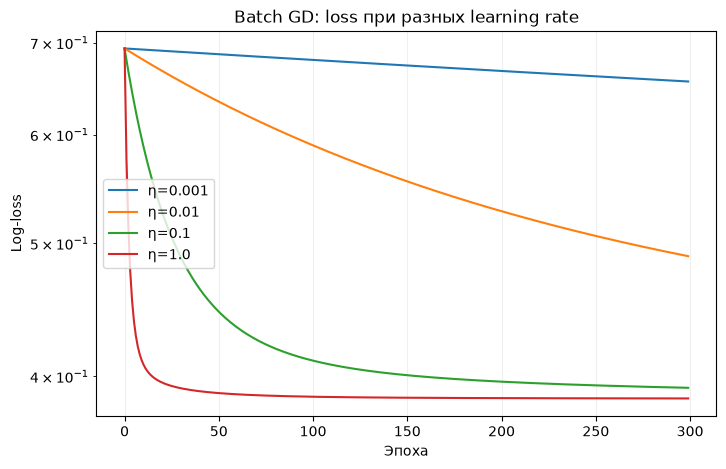

,eta,final_train_loss,val_ROC-AUC,val_AP,val_logloss
0,0.001,0.65578,0.68713,0.25425,0.65624
1,0.010,0.48924,0.68839,0.25638,0.49216
2,0.100,0.39235,0.70212,0.26819,0.40028
3,1.000,0.38541,0.70306,0.26342,0.39634


In [30]:
etas = [0.001, 0.01, 0.1, 1.0]
gd_runs = {}
plt.figure(figsize=(8, 5))
for eta in etas:
    w, hist = fit_batch_gd(Xg_tr_b, yg_tr, eta=eta, epochs=300)
    gd_runs[eta] = (w, hist)
    plt.plot(hist, label=f'η={eta}')
plt.yscale('log')
plt.xlabel('Эпоха')
plt.ylabel('Log-loss')
plt.title('Batch GD: loss при разных learning rate')
plt.legend(); plt.grid(alpha=0.2); plt.show()

eta_rows = []
for eta, (w, hist) in gd_runs.items():
    p = predict_proba_gd(Xg_val_b, w)
    eta_rows.append({
        'eta': eta,
        'final_train_loss': hist[-1],
        'val_ROC-AUC': roc_auc_score(yg_val, p),
        'val_AP': average_precision_score(yg_val, p),
        'val_logloss': log_loss(yg_val, p)
    })
display(pd.DataFrame(eta_rows).round(5))

### 6.3. Mini-batch и momentum

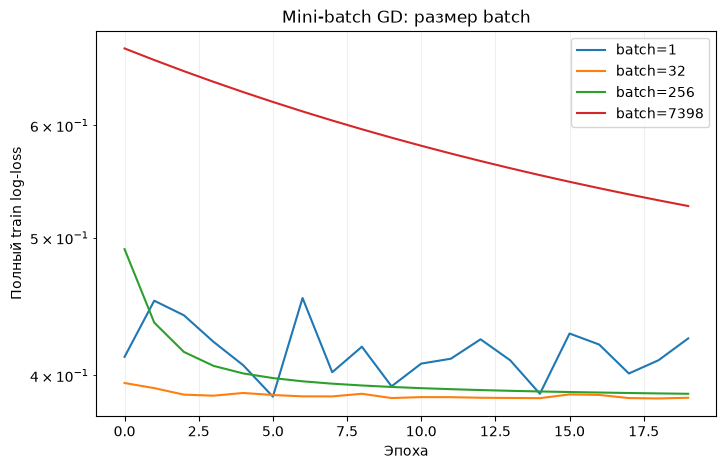

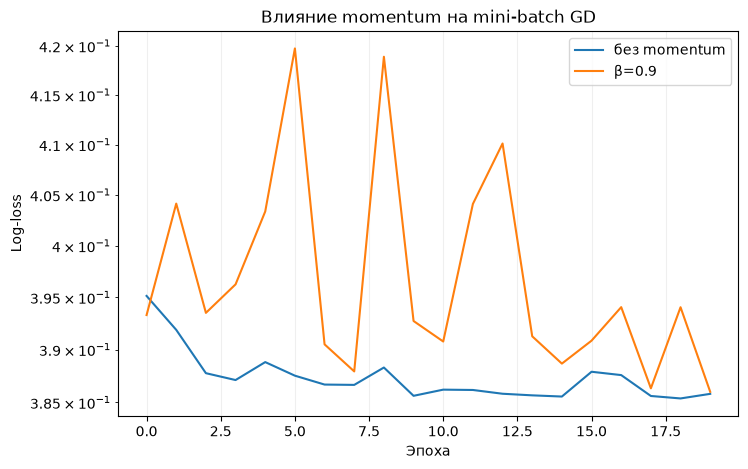

In [31]:
batch_sizes = [1, 32, 256, len(Xg_tr_b)]
mb_runs = {}
plt.figure(figsize=(8, 5))
for bs in batch_sizes:
    w, hist = fit_minibatch_gd(Xg_tr_b, yg_tr, eta=0.1, epochs=20, batch_size=bs, momentum=0.0)
    mb_runs[bs] = (w, hist)
    plt.plot(hist, label=f'batch={bs}')
plt.yscale('log')
plt.xlabel('Эпоха')
plt.ylabel('Полный train log-loss')
plt.title('Mini-batch GD: размер batch')
plt.legend(); plt.grid(alpha=0.2); plt.show()

w_no_mom, hist_no_mom = fit_minibatch_gd(Xg_tr_b, yg_tr, eta=0.1, epochs=20, batch_size=32, momentum=0.0)
w_mom, hist_mom = fit_minibatch_gd(Xg_tr_b, yg_tr, eta=0.1, epochs=20, batch_size=32, momentum=0.9)

plt.figure(figsize=(8, 5))
plt.plot(hist_no_mom, label='без momentum')
plt.plot(hist_mom, label='β=0.9')
plt.yscale('log')
plt.xlabel('Эпоха')
plt.ylabel('Log-loss')
plt.title('Влияние momentum на mini-batch GD')
plt.legend(); plt.grid(alpha=0.2); plt.show()

### 6.4. Согласование с sklearn

Для сравнения с `LogisticRegression(C=1)` используется та же стандартизация шести числовых признаков и L2-штраф. В среднем-log-loss постановке для `n` обучающих объектов эквивалентный коэффициент регуляризации равен `λ = 1/(C·n)` для необучаемого intercept.

In [32]:
C_match = 1.0
l2_lambda = 1.0 / (C_match * len(yg_tr))
w_match, hist_match = fit_batch_gd(
    Xg_tr_b, yg_tr, eta=0.1, epochs=3000, l2=l2_lambda
)

sk_lr = LogisticRegression(
    C=C_match,
    penalty='l2',
    solver='lbfgs',
    fit_intercept=False,
    max_iter=5000
)
sk_lr.fit(Xg_tr_b, yg_tr)

p_gd = predict_proba_gd(Xg_te_b, w_match)
p_sk = sk_lr.predict_proba(Xg_te_b)[:, 1]

compare = pd.DataFrame({
    'metric': ['ROC-AUC', 'AP', 'log-loss'],
    'GD from scratch': [roc_auc_score(yg_te, p_gd), average_precision_score(yg_te, p_gd), log_loss(yg_te, p_gd)],
    'sklearn LogisticRegression': [roc_auc_score(yg_te, p_sk), average_precision_score(yg_te, p_sk), log_loss(yg_te, p_sk)]
})
display(compare.round(5))
coef_cmp = pd.DataFrame({'GD': w_match, 'sklearn': sk_lr.coef_.ravel(), 'abs_diff': np.abs(w_match-sk_lr.coef_.ravel())})
display(coef_cmp.round(5))

,metric,GD from scratch,sklearn LogisticRegression
0,ROC-AUC,0.73142,0.72949
1,AP,0.32395,0.32197
2,log-loss,0.38320,0.38376


,GD,sklearn,abs_diff
0,-2.26014,-2.22783,0.03231
1,0.02339,0.01909,0.00430
2,0.09535,0.07982,0.01554
3,0.09824,0.10906,0.01082
4,-0.14556,0.19175,0.33731
5,-1.47916,-1.67108,0.19192
6,-0.27480,-0.27461,0.00019


## 7. Задание 6 — регуляризация

Исследуются `C ∈ {0.001, 0.01, 0.1, 1, 10, 100}` и L2/L1/Elastic Net там, где solver это поддерживает. Основной критерий выбора в эксперименте — AP на validation. Коэффициенты трактуются как условные ассоциации, а не как причинные эффекты.

In [33]:
C_grid = [0.001, 0.01, 0.1, 1, 10, 100]
reg_rows = []
reg_models_store = {}

for C in C_grid:
    for penalty, solver, l1_ratio in [
        ('l2', 'lbfgs', None),
        ('l1', 'liblinear', None),
        ('elasticnet', 'saga', 0.5),
    ]:
        kwargs = dict(C=C, penalty=penalty, solver=solver, max_iter=5000, random_state=RANDOM_STATE)
        if penalty == 'elasticnet':
            kwargs['l1_ratio'] = l1_ratio
        model = Pipeline([
            ('prep', clf_prep),
            ('model', LogisticRegression(**kwargs))
        ])
        model.fit(Xc_tr, yc_tr)
        p_val = model.predict_proba(Xc_val)[:, 1]
        Xt = model.named_steps['prep'].transform(Xc_tr)
        coef = model.named_steps['model'].coef_.ravel()
        reg_rows.append({
            'penalty': penalty,
            'C': C,
            'AP_validation': average_precision_score(yc_val, p_val),
            'ROC-AUC_validation': roc_auc_score(yc_val, p_val),
            'coef_L2_norm': np.linalg.norm(coef),
            'nonzero_coefficients': int(np.sum(np.abs(coef) > 1e-8)),
            'n_features': len(coef)
        })
        reg_models_store[(penalty, C)] = model

reg_results_cls = pd.DataFrame(reg_rows).sort_values(['penalty', 'C'])
display(reg_results_cls.round(5))

,penalty,C,AP_validation,ROC-AUC_validation,coef_L2_norm,nonzero_coefficients,n_features
2,elasticnet,0.001,0.24877,0.68527,0.04175,1,74
5,elasticnet,0.010,0.29013,0.72005,0.95508,10,74
8,elasticnet,0.100,0.30868,0.73732,1.67543,36,74
11,elasticnet,1.000,0.31108,0.73884,3.04778,59,74
14,elasticnet,10.000,0.31004,0.73800,4.96456,71,74
17,elasticnet,100.000,0.31013,0.73790,5.54529,74,74
1,l1,0.001,0.15450,0.50000,0.00000,0,74
4,l1,0.010,0.27261,0.71510,0.78689,7,74
7,l1,0.100,0.30957,0.73834,1.60910,24,74
10,l1,1.000,0.31139,0.73946,3.01261,51,74


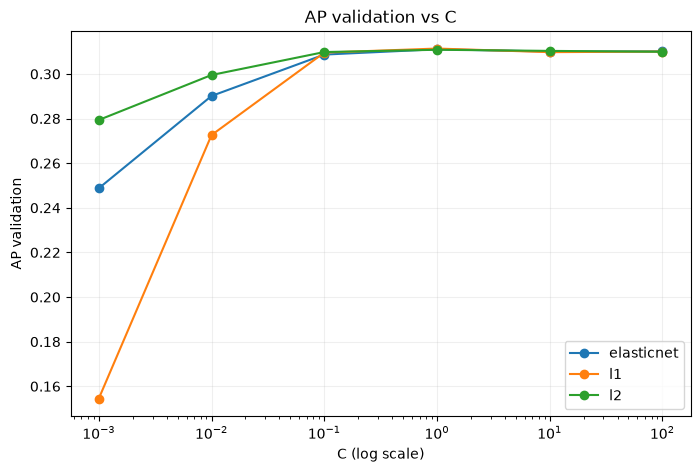

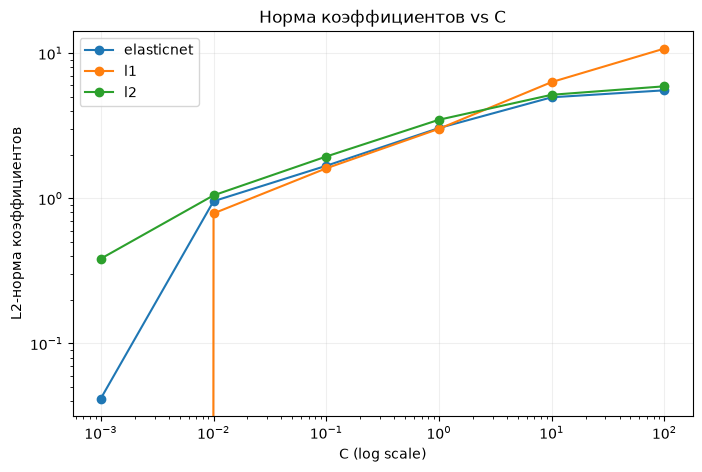

In [34]:
plt.figure(figsize=(8, 5))
for penalty, grp in reg_results_cls.groupby('penalty'):
    plt.semilogx(grp['C'], grp['AP_validation'], marker='o', label=penalty)
plt.xlabel('C (log scale)')
plt.ylabel('AP validation')
plt.title('AP validation vs C')
plt.legend(); plt.grid(alpha=0.2); plt.show()

plt.figure(figsize=(8, 5))
for penalty, grp in reg_results_cls.groupby('penalty'):
    plt.loglog(grp['C'], grp['coef_L2_norm'], marker='o', label=penalty)
plt.xlabel('C (log scale)')
plt.ylabel('L2-норма коэффициентов')
plt.title('Норма коэффициентов vs C')
plt.legend(); plt.grid(alpha=0.2); plt.show()

### 7.1. Топ-10 коэффициентов

Имена признаков извлекаются после one-hot encoding, поэтому категориальные коэффициенты сохраняются с исходными именами категорий.

In [35]:
main_model = clf_models['LogisticRegression']
feature_names = main_model.named_steps['prep'].get_feature_names_out()
coef = main_model.named_steps['model'].coef_.ravel()
coef_table = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
top10 = coef_table.sort_values('abs_coefficient', ascending=False).head(10)
display(top10[['feature', 'coefficient']].round(5))

,feature,coefficient
7,num__ExitRates,-1.58976
38,cat__Browser_12,1.20567
11,cat__Month_Feb,-1.05639
63,cat__TrafficType_15,-1.04036
33,cat__Browser_7,-0.69772
55,cat__TrafficType_7,0.65040
57,cat__TrafficType_9,-0.60574
29,cat__Browser_3,-0.59993
62,cat__TrafficType_14,-0.59044
16,cat__Month_Nov,0.56439


## 8*. Продвинутый анализ (выполняется при наличии времени)

Ниже автоматизированы три расширения из методички: сравнение random split с month holdout, сравнение модели с/без `PageValues` и bootstrap-интервалы ROC-AUC/AP. Важное ограничение: в данных нет года, поэтому month holdout не является полноценным «будущим годом».

In [36]:
# 8.1 Month holdout: последний наблюдаемый месяц по календарному порядку.
month_order = ['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Sep', 'Nov', 'Dec']
month_order = [m for m in month_order if m in df['Month'].unique()]
if len(month_order) >= 2:
    holdout_month = month_order[-1]
    train_mask = df['Month'] != holdout_month
    test_mask = df['Month'] == holdout_month
    print('Holdout month:', holdout_month, '| train:', train_mask.sum(), '| test:', test_mask.sum())
else:
    print('Недостаточно уникальных месяцев для month holdout.')

Holdout month: Dec | train: 10603 | test: 1727


In [37]:
# 8.2 PageValues: конец сессии vs раннее решение
# Сравниваем ту же логистическую модель на признаках без и с PageValues.
all_cls_features = num_cols + cat_cols
X_full_cls = df[all_cls_features]
Xf_tr, Xf_val, Xf_te, yf_tr, yf_val, yf_te = classification_split(X_full_cls, yc)

prep_with_pv = make_preprocessor(num_cols, cat_cols, dense=True)
clf_with_pv = Pipeline([
    ('prep', prep_with_pv),
    ('model', LogisticRegression(max_iter=3000, C=1.0, solver='lbfgs'))
])
clf_with_pv.fit(Xf_tr, yf_tr)
p_with_pv = clf_with_pv.predict_proba(Xf_te)[:,1]
p_without_pv = probs_test['LogisticRegression']

print('Без PageValues — ROC-AUC:', roc_auc_score(yc_te, p_without_pv), 'AP:', average_precision_score(yc_te, p_without_pv))
print('С PageValues   — ROC-AUC:', roc_auc_score(yf_te, p_with_pv), 'AP:', average_precision_score(yf_te, p_with_pv))

Без PageValues — ROC-AUC: 0.7601333018460271 AP: 0.36945069962959576
С PageValues   — ROC-AUC: 0.8954047793711247 AP: 0.6312470233548355


In [38]:
# 8.3 Bootstrap confidence intervals for ROC-AUC and AP on the fixed test predictions
rng = np.random.default_rng(RANDOM_STATE)

def bootstrap_ci(y_true, prob, metric_fn, B=1000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    prob = np.asarray(prob)
    vals = []
    n = len(y_true)
    for _ in range(B):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        vals.append(metric_fn(y_true[idx], prob[idx]))
    vals = np.asarray(vals)
    return {
        'estimate': metric_fn(y_true, prob),
        'low_2.5%': np.percentile(vals, 2.5),
        'high_97.5%': np.percentile(vals, 97.5),
        'n_boot': len(vals)
    }

ci_rows = []
for metric_name, fn in [('ROC-AUC', roc_auc_score), ('AP', average_precision_score)]:
    res = bootstrap_ci(yc_te, p_test_lr, fn)
    res['metric'] = metric_name
    ci_rows.append(res)
display(pd.DataFrame(ci_rows).set_index('metric').round(4))

,estimate,low_2.5%,high_97.5%,n_boot
metric,,,,
ROC-AUC,0.7601,0.7359,0.7835,1000
AP,0.3695,0.3228,0.4202,1000


## 9. Сохранение результатов

Ячейка ниже собирает основные таблицы в один CSV и сохраняет ключевые артефакты. Это удобно для приложения к отчёту и проверки преподавателем.

In [39]:
out_dir = Path('lab2_outputs')
out_dir.mkdir(exist_ok=True)

reg_results.to_csv(out_dir/'regression_metrics.csv', index=False)
log1p_rows.to_csv(out_dir/'regression_log1p_metrics.csv', index=False)
clf_results.to_csv(out_dir/'classification_metrics.csv', index=False)
threshold_results.to_csv(out_dir/'threshold_metrics.csv', index=False)
reg_results_cls.to_csv(out_dir/'regularization_metrics.csv', index=False)
top10.to_csv(out_dir/'top10_coefficients.csv', index=False)

# Официальный источник / версии / параметры reproducibility
meta = pd.DataFrame([
    ['data_source', data_source],
    ['random_state', RANDOM_STATE],
    ['python', sys.version.split()[0]],
    ['pandas', pd.__version__],
    ['scikit-learn', sklearn_version],
    ['split', '60/20/20'],
    ['classification_pagevalues', 'excluded from early baseline'],
], columns=['item', 'value'])
meta.to_csv(out_dir/'run_metadata.csv', index=False)

print('Сохранено в', out_dir.resolve())
for p in sorted(out_dir.iterdir()):
    print(p.name)

Сохранено в /Users/nagiev/university/Applied Machine Learning/lab2/lab2_outputs
classification_metrics.csv
regression_log1p_metrics.csv
regression_metrics.csv
regularization_metrics.csv
run_metadata.csv
threshold_metrics.csv
top10_coefficients.csv


## 10. Выводы — шаблон, который после запуска заменяется фактическими числами

1. Сначала сравнивается качество регрессоров с `DummyRegressor`; это отделяет сам факт наличия сигнала от качества сложной модели.
2. Для `PageValues` необходимо учитывать нули и длинный правый хвост; `log1p` и устойчивые функции потерь — естественные следующие эксперименты.
3. Для `Revenue` accuracy нельзя рассматривать отдельно от дисбаланса классов; обязательны AP, ROC-AUC, log-loss и метрики при выбранном пороге.
4. Порог max-utility выбирается исключительно по validation и затем фиксируется для test.
5. Gradient check с малой относительной ошибкой подтверждает корректность аналитического градиента; scaling существенно влияет на скорость сходимости.
6. Регуляризация управляет величиной и структурой коэффициентов; интерпретация остаётся ассоциативной, не причинной.

**Ограничения:** отсутствие года и точной временной метки мешает строгому temporal holdout; `PageValues` нельзя без оговорки использовать в раннем решении; class weighting меняет вероятности и требует отдельной проверки калибровки.